In [6]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt
import pyomo.environ as pe

import good
from good.reload import deep_reload

In [51]:
'''
Loading graph and policies
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/California.json')

policies = {
    'california_ps':{
        '_class': 'Portfolio_Standard',
        'ratio': 0.45,
        'inclusion_criteria': {
            0: "lambda a: a.get('renewable', True)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
        'exclusion_criteria': {
            0: "lambda a: not a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
    },
    'california_ct': {
        '_class': 'Capacity_Target',
        'target': 70e9,
        'inclusion_criteria': {
            0: "lambda a: a.get('renewable', True)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
    },
    'california_rm' : {
        '_class': 'Reserve_Margin',
        'margin': .1,
        'sign': -1,
        'demand_criteria': {
            2: "lambda a: a.get('type', '') == 'load'",
        },
        'supply_criteria': {
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
        },
    },
}

for source, node in graph._node.items():
    for key, asset in node.get('assets', {}).items():

        asset['capex_cost'] /= (52 * 5)

In [68]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(
    graph, policies = policies
)

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.198561429977417
Variables Built: 1.0552260875701904
Constraints Built: 1.8692278861999512
Objective Built: 0.13666486740112305


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 120810, continuous_variables = 46537, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 46537), overall = Bunch(binary_variables = 0, constraints = 120810, continuous_variables = 46537, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 46537), warning = Bunch(unassociated_disjuncts = 0))

In [69]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

setattr(network.model, 'california_ps::ratio', .3)

network.solve(**kw)
solution = network.solution

Problem Solved: 2.8081576824188232
Results Collected: 1.640165090560913


In [70]:
pe.value(network.model.objective)

28861869.862618394

In [71]:
solution.nodes

NodeView(('WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID', 'WECC_SCE'))

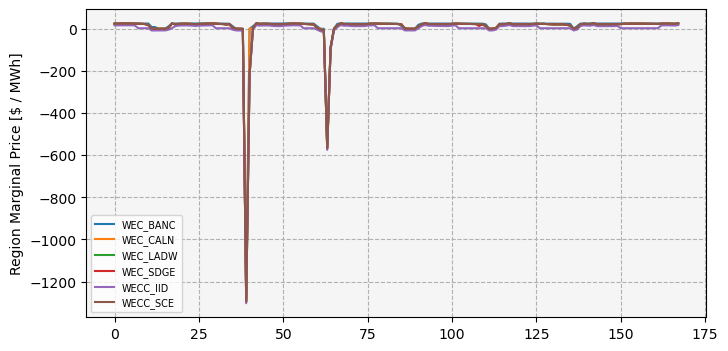

In [72]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))

for source, node in solution._node.items():

    ax.plot(
        np.array(node['clearing_price']) * 3.6e9,
        label = source,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Region Marginal Price [$ / MWh]',
}

ax.set(**kw)

kw = {
    'ls': '--',
}

ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

ax.legend(**kw)

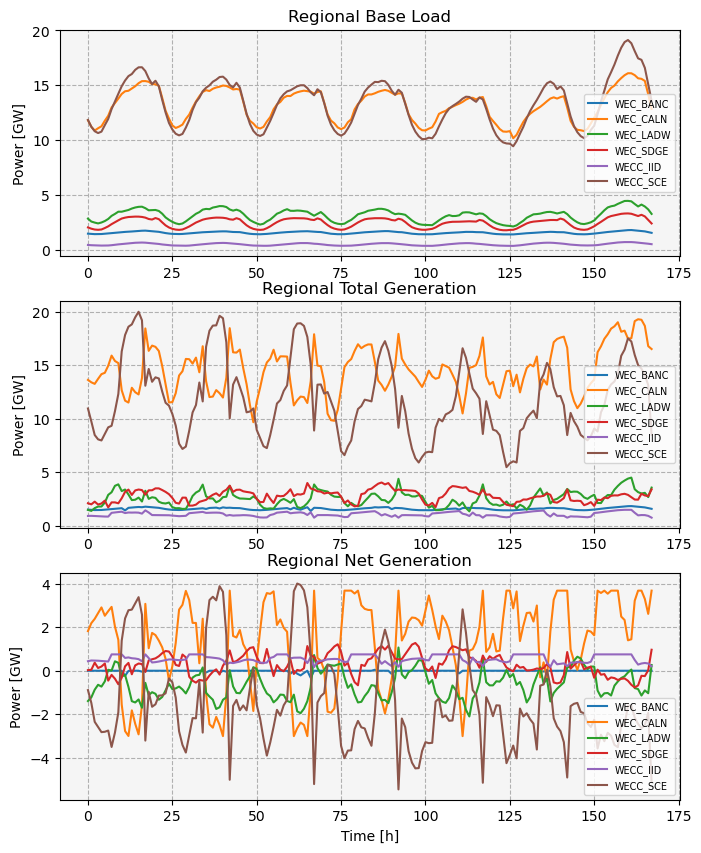

In [73]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in solution._node.items():

    ax[0].plot(
        -np.array(node['assets'][f"base_load_{source}"]['net']) / 1e9,
        label = source,
    )
    
    ax[0].set_title('Regional Base Load')

for source, node in solution._node.items():

    values = np.vstack(
        [v["net"] for k, v in node['assets'].items() if "base" not in k]
    )

    ax[1].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[1].set_title('Regional Total Generation')

for source, node in solution._node.items():

    values = np.vstack(
        [v["net"] for k, v in node['assets'].items()]
    )

    ax[2].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[2].set_title('Regional Net Generation')
    ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

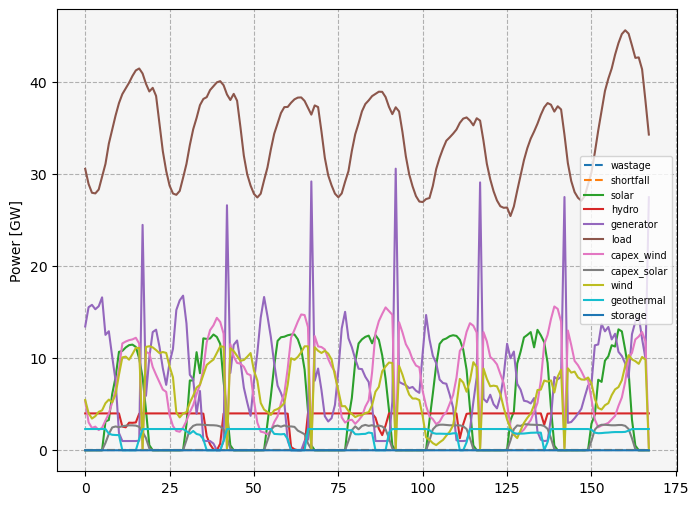

In [76]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in solution._node.items():

    gen_amounts['wastage'].append(node['wastage'])
    gen_amounts['shortfall'].append(node['shortfall'])

for source, node in solution._node.items():

    for asset in node['assets'].values():

        # print(asset)

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [node['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [node['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

gen_amounts['load'] *= -1

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

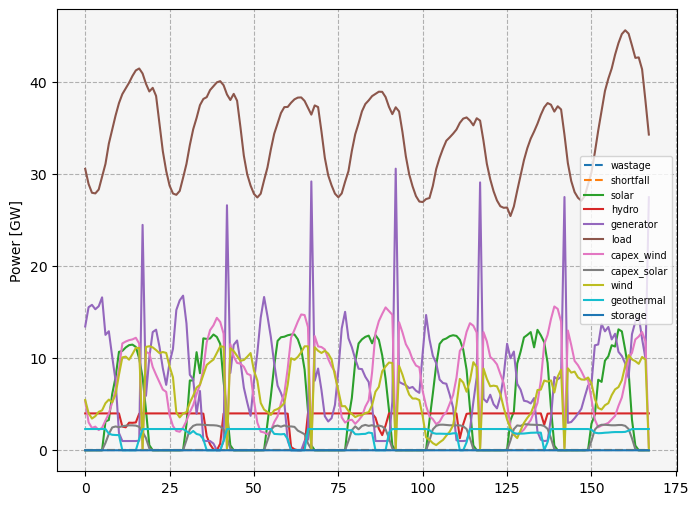

In [76]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in solution._node.items():

    gen_amounts['wastage'].append(node['wastage'])
    gen_amounts['shortfall'].append(node['shortfall'])

for source, node in solution._node.items():

    for asset in node['assets'].values():

        # print(asset)

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [node['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [node['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

gen_amounts['load'] *= -1

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

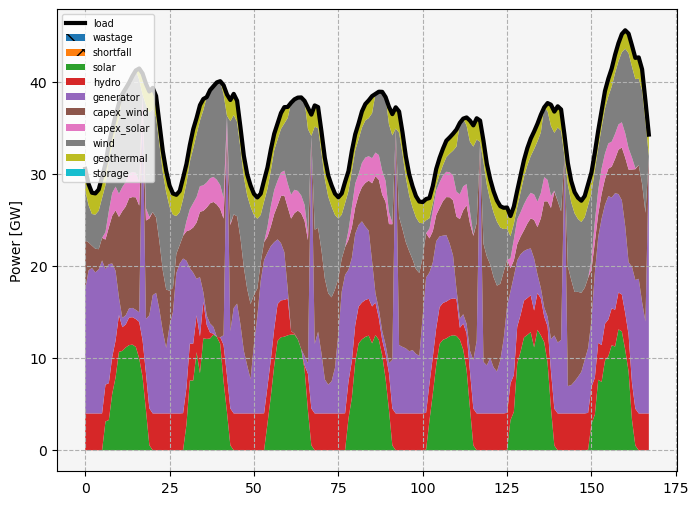

In [98]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in solution._node.items():

    gen_amounts['wastage'].append(node['wastage'])
    gen_amounts['shortfall'].append(node['shortfall'])

for source, node in solution._node.items():

    for asset in node['assets'].values():

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [node['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [node['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

load = gen_amounts.pop('load')

n = len(load)
prev = np.zeros(n)
x = np.arange(0, n)

ax.plot(x, -load, label = 'load', color = 'k', lw = 3)

k = 1
for key, val in gen_amounts.items():

    k += 1

    ax.fill_between(
        x,
        prev,
        prev + val,
        label = key,
        hatch = 'x' if key in ['wastage', 'shortfall'] else None,
    )

    prev += val

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

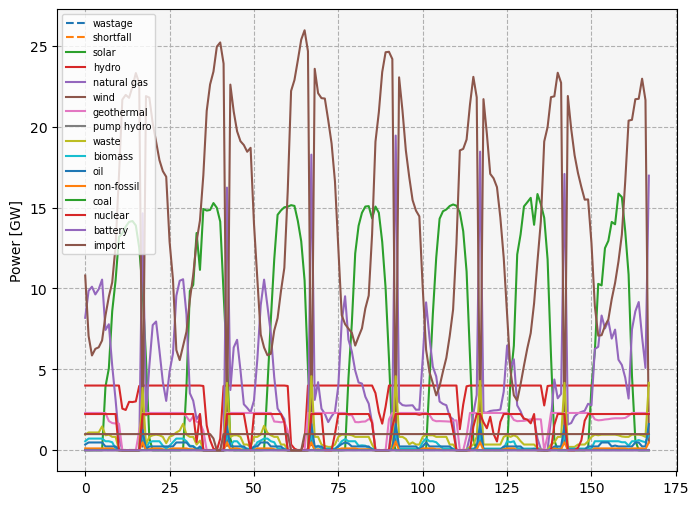

In [99]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in solution._node.items():

    gen_amounts['wastage'].append(node['wastage'])
    gen_amounts['shortfall'].append(node['shortfall'])

for source, node in solution._node.items():

    for asset in node['assets'].values():

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in gen_amounts:

            gen_amounts[asset['fuel']] = (
                [node['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['fuel']].append(
                [node['assets'][asset['id']]['net']]
            )

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

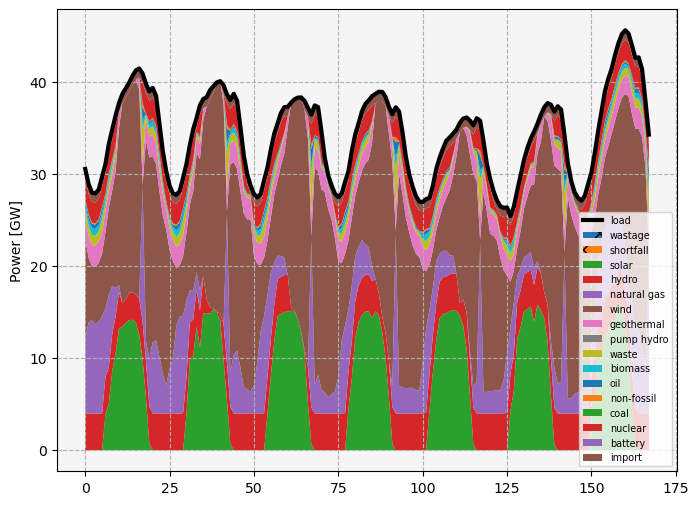

In [102]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in solution._node.items():

    gen_amounts['wastage'].append(node['wastage'])
    gen_amounts['shortfall'].append(node['shortfall'])

for source, node in solution._node.items():

    for asset in node['assets'].values():

        if 'fuel' not in asset:

            asset['fuel'] = 'load'

        if asset['fuel'] not in gen_amounts:

            gen_amounts[asset['fuel']] = (
                [node['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['fuel']].append(
                [node['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

load = gen_amounts.pop('load')

n = len(load)
prev = np.zeros(n)
x = np.arange(0, n)

ax.plot(x, -load, label = 'load', color = 'k', lw = 3)

k = 1
for key, val in gen_amounts.items():

    k += 1

    ax.fill_between(
        x,
        prev,
        prev + val,
        label = key,
        hatch = 'x' if key in ['wastage', 'shortfall'] else None,
    )

    prev += val

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

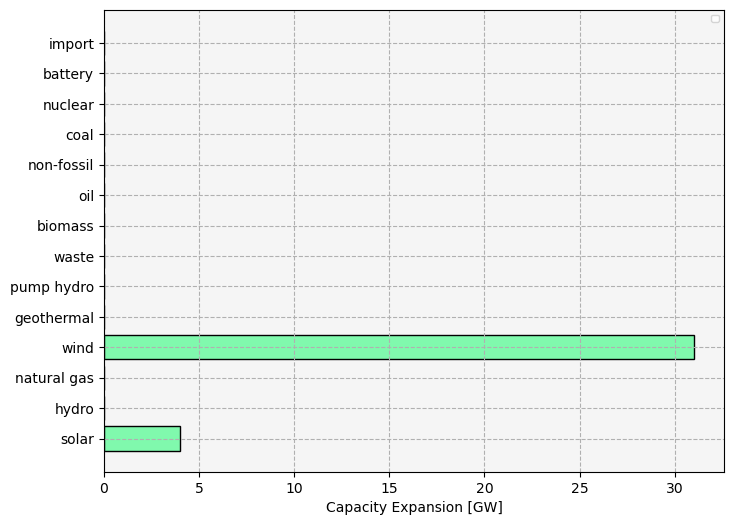

In [80]:
capex_amounts = {}

for source, node in solution._node.items():

    for asset in node['assets'].values():

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in capex_amounts:

            capex_amounts[asset['fuel']] = (
                [node['assets'][asset['id']]['capex']]
            )

        else:

            capex_amounts[asset['fuel']].append(
                [node['assets'][asset['id']]['capex']]
            )

for key, val in capex_amounts.items():

    capex_amounts[key] = np.vstack(val).sum(axis = 0)[0] / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

kw = {
    'color': 'xkcd:seafoam',
    'ec': 'k',
}

ax.barh(list(capex_amounts.keys()), list(capex_amounts.values()), **kw)

kw = {
    'facecolor': 'whitesmoke',
    'xlabel': 'Capacity Expansion [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)